# GIVE ME SOME CREDIT

Ссылка на соревнование: https://www.kaggle.com/competitions/GiveMeSomeCredit/overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="darkgrid")

import warnings
warnings.filterwarnings('ignore')

In [2]:
train_data = pd.read_csv('cs-training.csv')
test_data = pd.read_csv('cs-test.csv')

In [3]:
train_data.drop(columns=["Unnamed: 0"], inplace=True)
test_data.drop(columns=["Unnamed: 0"], inplace=True)

In [4]:
train_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


**Описание данных:**

In [5]:
pd.set_option('max_colwidth', 200)
description = pd.read_excel("Data Dictionary.xls", skiprows=1)
description.head(15)

,Variable Name,Description,Type
0,SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
1,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
2,age,Age of borrower in years,integer
3,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
4,DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
5,MonthlyIncome,Monthly income,real
6,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
7,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
8,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer
9,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days past due but no worse in the last 2 years.,integer


# Exploratory Data Analysis

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

Заметим, что:

- В тренировочных данных 150000 строк и 11 признаков
- Все значения числовые
- В столбцах **MonthlyIncome** и **NumberOfDependents** есть пропущенные значения

In [7]:
train_data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Теперь посмотрим на тестовые данные.

In [8]:
test_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [9]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      0 non-null       float64
 1   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 2   age                                   101503 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 4   DebtRatio                             101503 non-null  float64
 5   MonthlyIncome                         81400 non-null   float64
 6   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 7   NumberOfTimes90DaysLate               101503 non-null  int64  
 8   NumberRealEstateLoansOrLines          101503 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 10  NumberOfDependents                    98877 non-null   float64
dtype

Видим пропуски в тех же столбцах, что и в тренировочной выборке.

In [10]:
test_data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


In [11]:
final_train = train_data.copy()
final_test = test_data.copy()

Удалим таргет из тестовой выборки.

In [12]:
final_test.drop('SeriousDlqin2yrs', axis=1, inplace=True)

Посмотрим на баланс классов целевой переменной.

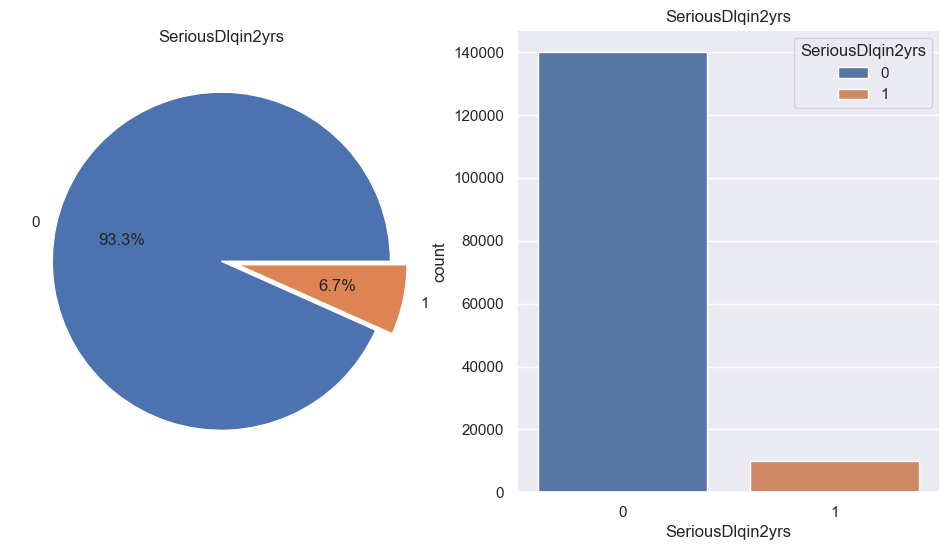

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
final_train['SeriousDlqin2yrs'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('SeriousDlqin2yrs')
axes[0].set_ylabel('')

sns.countplot(x='SeriousDlqin2yrs', data=final_train, hue='SeriousDlqin2yrs', ax=axes[1])
axes[1].set_title('SeriousDlqin2yrs')
plt.show()

Доля положительного класса составляет 6.7%, что говорит о сильном дисбалансе классов.

Перейдём к анализу выбросов.

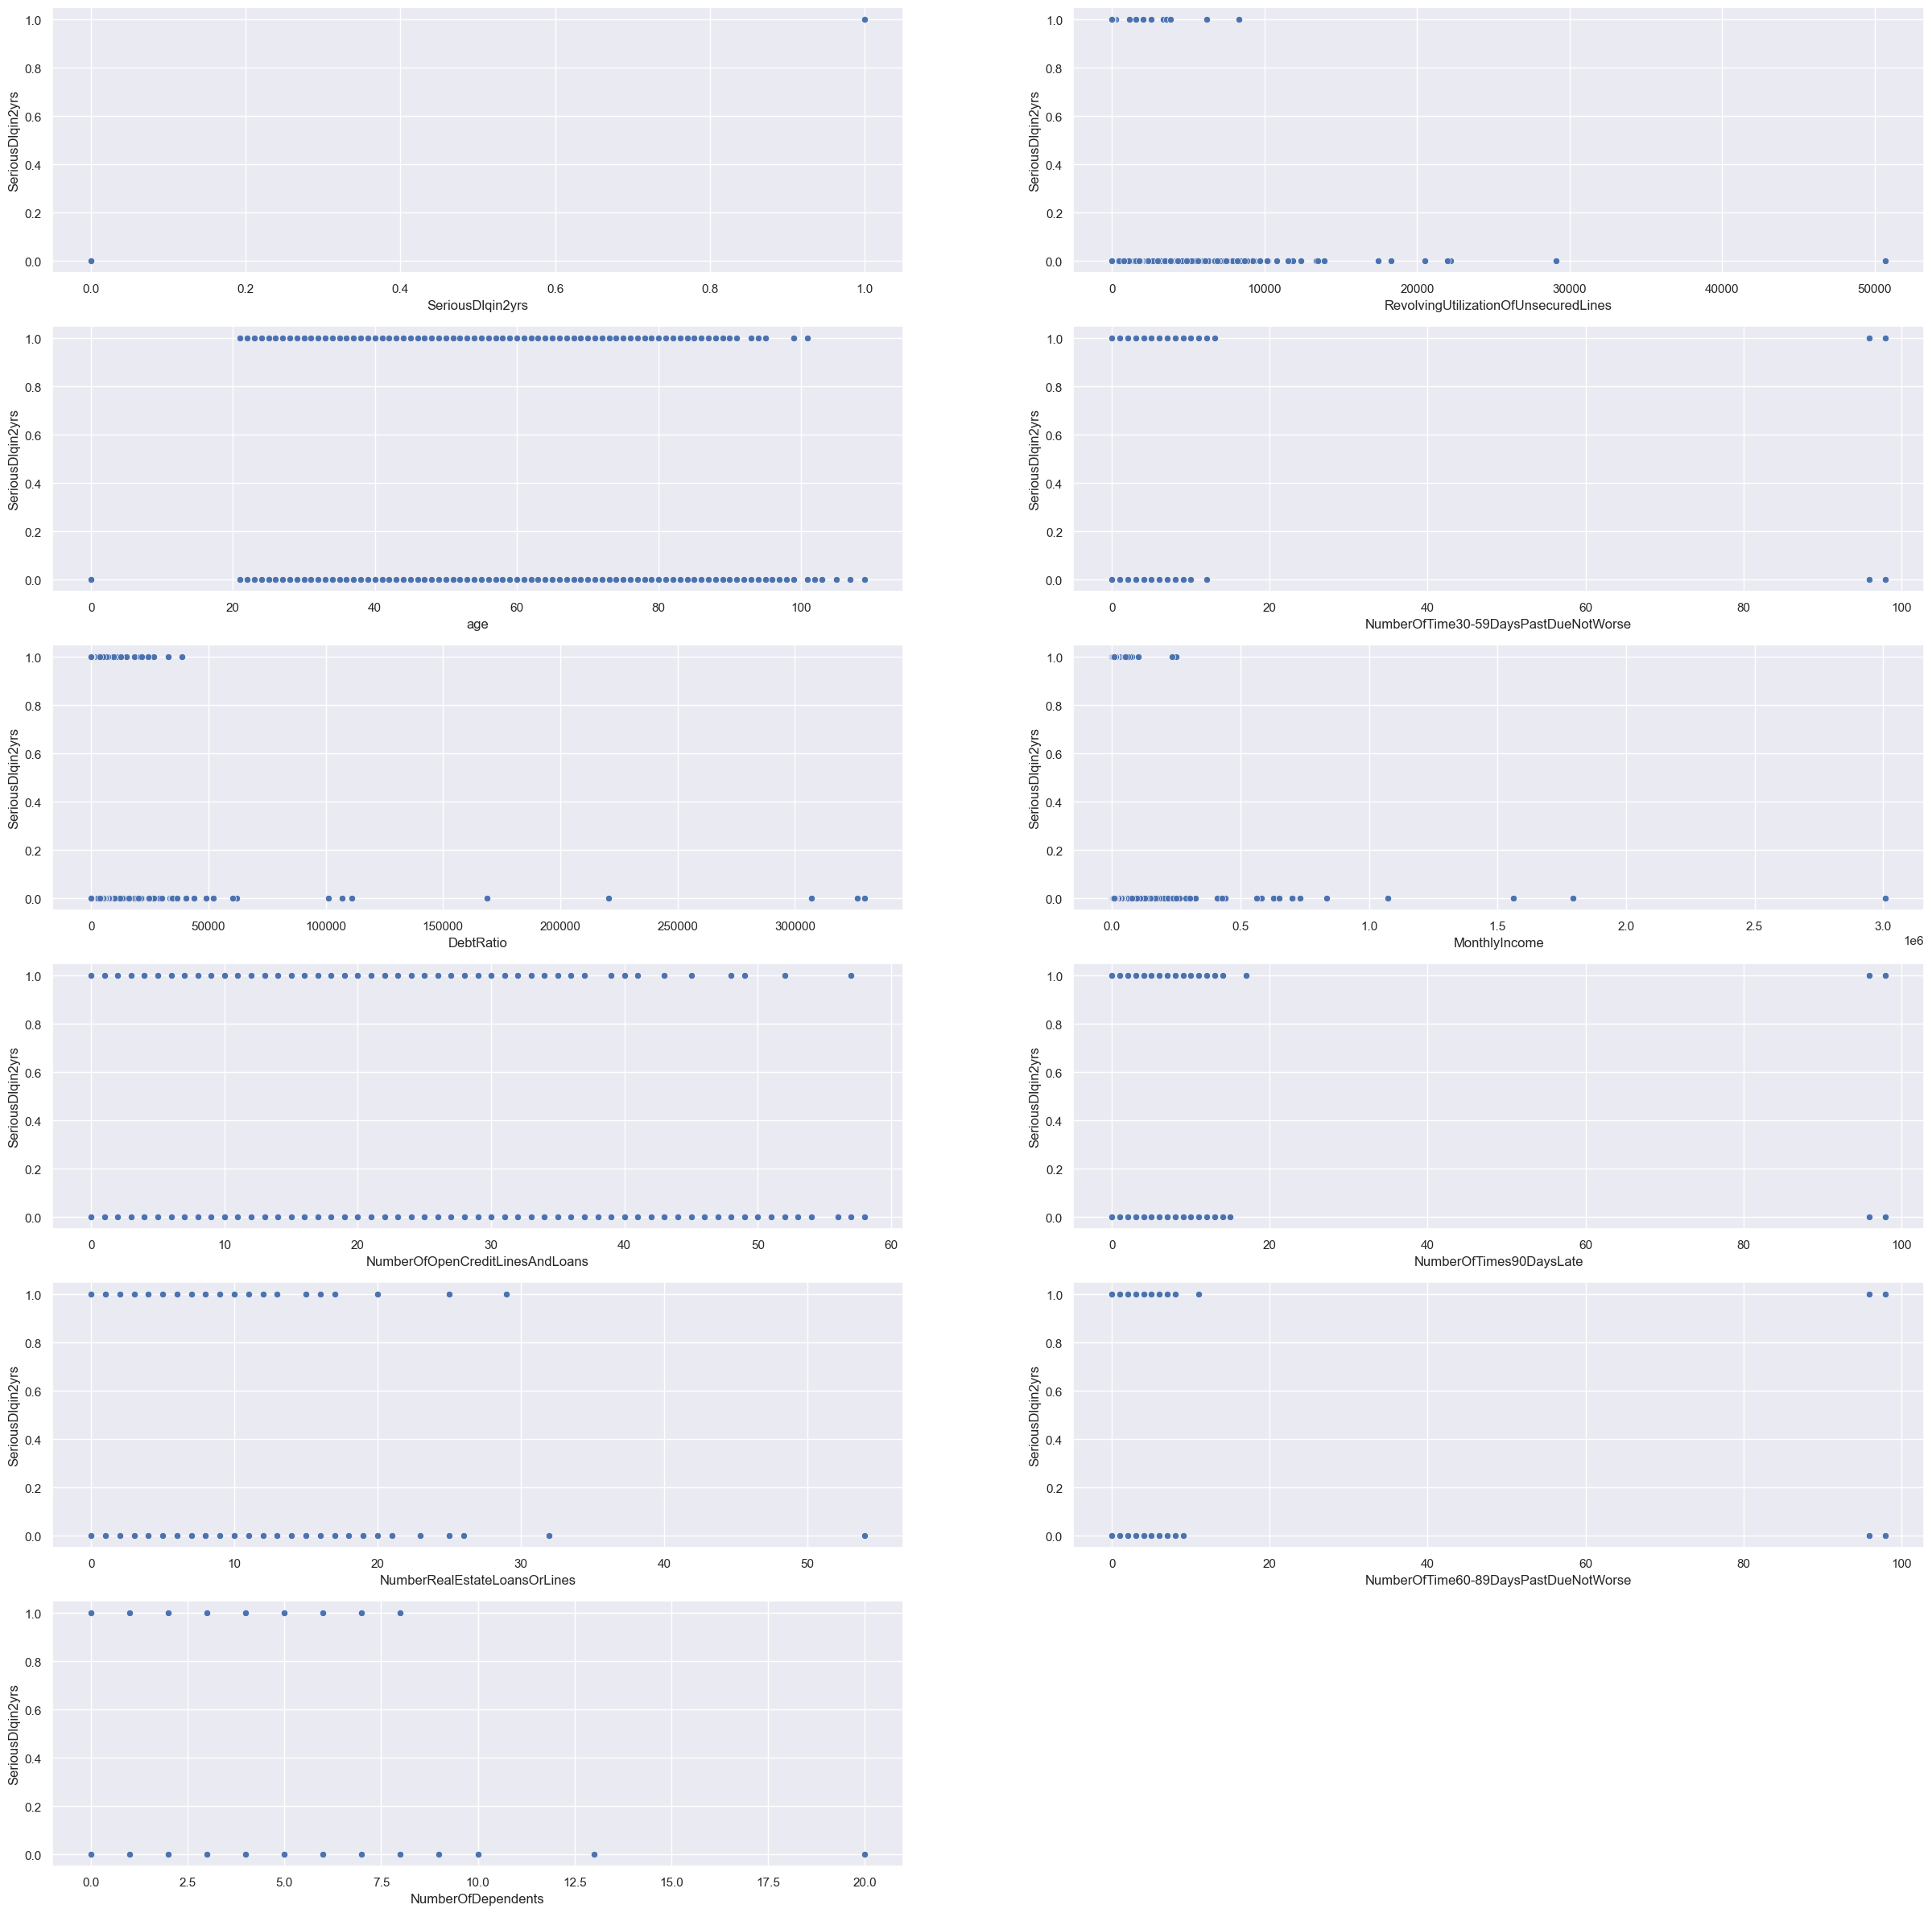

In [14]:
fig = plt.figure(figsize=(30, 30))
for i, col in enumerate(final_train.columns):
    axes = fig.add_subplot(6, 2, i + 1)  # i не может быть равным 0
    sns.scatterplot(x=col, y='SeriousDlqin2yrs', data=final_train, ax=axes)
plt.show()

Из приведенных выше графиков мы можем наблюдать следующее:

- В столбцах **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTime60-89DaysPastDueNotWorse** и **NumberOfTimes90DaysLate** есть  значения, у которых количество просрочек близко к 100, что сильно выше остальных значений в этих столбцах.
- Также необычно высокие значения есть в столбцах **DebtRatio** и **RevolvingUtilizationOfUnsecuredLines**.

Внесем изменения в столбцы **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTime60-89DaysPastDueNotWorse** и **NumberOfTimes90DaysLate**.

In [15]:
print("Уникальные значения в '30-59 Days' >= 90:                 ",
      np.unique(final_train[final_train['NumberOfTime30-59DaysPastDueNotWorse'] >= 90]['NumberOfTime30-59DaysPastDueNotWorse']))

print("Уникальные значения в '60-89 Days' при '30-59 Days' >= 90:",
      np.unique(final_train[final_train['NumberOfTime30-59DaysPastDueNotWorse'] >= 90]['NumberOfTime60-89DaysPastDueNotWorse']))

print("Уникальные значения в '90 Days' при '30-59 Days' >= 90:   ",
      np.unique(final_train[final_train['NumberOfTime30-59DaysPastDueNotWorse'] >= 90]['NumberOfTimes90DaysLate']))

print("Уникальные значения в '30-59 Days' < 90:                  ",
      np.unique(final_train[final_train['NumberOfTime30-59DaysPastDueNotWorse'] < 90]['NumberOfTime30-59DaysPastDueNotWorse']))

print("Уникальные значения в '60-89 Days' при '30-59 Days' < 90: ",
      np.unique(final_train[final_train['NumberOfTime30-59DaysPastDueNotWorse'] < 90]['NumberOfTime60-89DaysPastDueNotWorse']))

print("Уникальные значения в '90 Days' при '30-59 Days' < 90:    ",
      np.unique(final_train[final_train['NumberOfTime30-59DaysPastDueNotWorse'] < 90]['NumberOfTimes90DaysLate']))

print("\nДоля положительного класса в таргете при значениях [96, 98]:",
      round(np.mean(final_train[final_train['NumberOfTime30-59DaysPastDueNotWorse'] >= 90]['SeriousDlqin2yrs']) * 100, 2), '%')

Уникальные значения в '30-59 Days' >= 90:                  [96 98]
Уникальные значения в '60-89 Days' при '30-59 Days' >= 90: [96 98]
Уникальные значения в '90 Days' при '30-59 Days' >= 90:    [96 98]
Уникальные значения в '30-59 Days' < 90:                   [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Уникальные значения в '60-89 Days' при '30-59 Days' < 90:  [ 0  1  2  3  4  5  6  7  8  9 11]
Уникальные значения в '90 Days' при '30-59 Days' < 90:     [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17]

Доля положительного класса в таргете при значениях [96, 98]: 54.65 %


Из приведенного выше видно, что когда значения в столбце **NumberOfTime30-59DaysPastDueNotWorse** >= 90, другие столбцы, в которых записано количество просрочек платежей на X дней, также имеют значения >= 90. Мы классифицируем их как особые метки, поскольку доля положительного класса у  них аномально высока и составляет 54.65%.  
Значения 96 и 98 можно рассматривать как ошибки учета, поэтому мы заменим их максимальным значением до 90, т.е. 13, 11 и 17.

In [16]:
final_train.loc[final_train['NumberOfTime30-59DaysPastDueNotWorse'] >= 90, 'NumberOfTime30-59DaysPastDueNotWorse'] = 13
final_train.loc[final_train['NumberOfTime60-89DaysPastDueNotWorse'] >= 90, 'NumberOfTime60-89DaysPastDueNotWorse'] = 11
final_train.loc[final_train['NumberOfTimes90DaysLate'] >= 90, 'NumberOfTimes90DaysLate'] = 17

In [17]:
print("Уникальные значения в '30-59 Days':", np.unique(final_train['NumberOfTime30-59DaysPastDueNotWorse']))
print("Уникальные значения в '60-89 Days':", np.unique(final_train['NumberOfTime60-89DaysPastDueNotWorse']))
print("Уникальные значения в '90 Days'   :", np.unique(final_train['NumberOfTimes90DaysLate']))

Уникальные значения в '30-59 Days': [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Уникальные значения в '60-89 Days': [ 0  1  2  3  4  5  6  7  8  9 11]
Уникальные значения в '90 Days'   : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17]


Проведем аналогичный анализ на тестовых данных.

In [18]:
print("Уникальные значения в '30-59 Days' >= 90:                 ",
      np.unique(final_test[final_test['NumberOfTime30-59DaysPastDueNotWorse'] >= 90]['NumberOfTime30-59DaysPastDueNotWorse']))

print("Уникальные значения в '60-89 Days' при '30-59 Days' >= 90:",
      np.unique(final_test[final_test['NumberOfTime30-59DaysPastDueNotWorse'] >= 90]['NumberOfTime60-89DaysPastDueNotWorse']))

print("Уникальные значения в '90 Days' при '30-59 Days' >= 90:   ",
      np.unique(final_test[final_test['NumberOfTime30-59DaysPastDueNotWorse'] >= 90]['NumberOfTimes90DaysLate']))

print("Уникальные значения в '30-59 Days' < 90:                  ",
      np.unique(final_test[final_test['NumberOfTime30-59DaysPastDueNotWorse'] < 90]['NumberOfTime30-59DaysPastDueNotWorse']))

print("Уникальные значения в '60-89 Days' при '30-59 Days' < 90: ",
      np.unique(final_test[final_test['NumberOfTime30-59DaysPastDueNotWorse'] < 90]['NumberOfTime60-89DaysPastDueNotWorse']))

print("Уникальные значения в '90 Days' при '30-59 Days' < 90:    ",
      np.unique(final_test[final_test['NumberOfTime30-59DaysPastDueNotWorse'] < 90]['NumberOfTimes90DaysLate']))

Уникальные значения в '30-59 Days' >= 90:                  [96 98]
Уникальные значения в '60-89 Days' при '30-59 Days' >= 90: [96 98]
Уникальные значения в '90 Days' при '30-59 Days' >= 90:    [96 98]
Уникальные значения в '30-59 Days' < 90:                   [ 0  1  2  3  4  5  6  7  8  9 10 11 12 19]
Уникальные значения в '60-89 Days' при '30-59 Days' < 90:  [0 1 2 3 4 5 6 7 8 9]
Уникальные значения в '90 Days' при '30-59 Days' < 90:     [ 0  1  2  3  4  5  6  7  8  9 10 11 12 16 17 18]


Здесь аналогичная ситуация. Проделаем те же действия, что и на тренировочной выборке:

In [19]:
final_test.loc[final_test['NumberOfTime30-59DaysPastDueNotWorse'] >= 90, 'NumberOfTime30-59DaysPastDueNotWorse'] = 19
final_test.loc[final_test['NumberOfTime60-89DaysPastDueNotWorse'] >= 90, 'NumberOfTime60-89DaysPastDueNotWorse'] = 9
final_test.loc[final_test['NumberOfTimes90DaysLate'] >= 90, 'NumberOfTimes90DaysLate'] = 18

print("Уникальные значения в '30-59 Days':", np.unique(final_test['NumberOfTime30-59DaysPastDueNotWorse']))
print("Уникальные значения в '60-89 Days':", np.unique(final_test['NumberOfTime60-89DaysPastDueNotWorse']))
print("Уникальные значения в '90 Days'   :", np.unique(final_test['NumberOfTimes90DaysLate']))

Уникальные значения в '30-59 Days': [ 0  1  2  3  4  5  6  7  8  9 10 11 12 19]
Уникальные значения в '60-89 Days': [0 1 2 3 4 5 6 7 8 9]
Уникальные значения в '90 Days'   : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 16 17 18]


Теперь посмотрим на колонки **DebtRatio** и **RevolvingUtilizationOfUnsecuredLines**.

In [20]:
print('Debt Ratio:')
print(final_train['DebtRatio'].describe())
print('\nRevolving Utilization of Unsecured Lines:')
print(final_train['RevolvingUtilizationOfUnsecuredLines'].describe())

Debt Ratio:
count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64

Revolving Utilization of Unsecured Lines:
count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


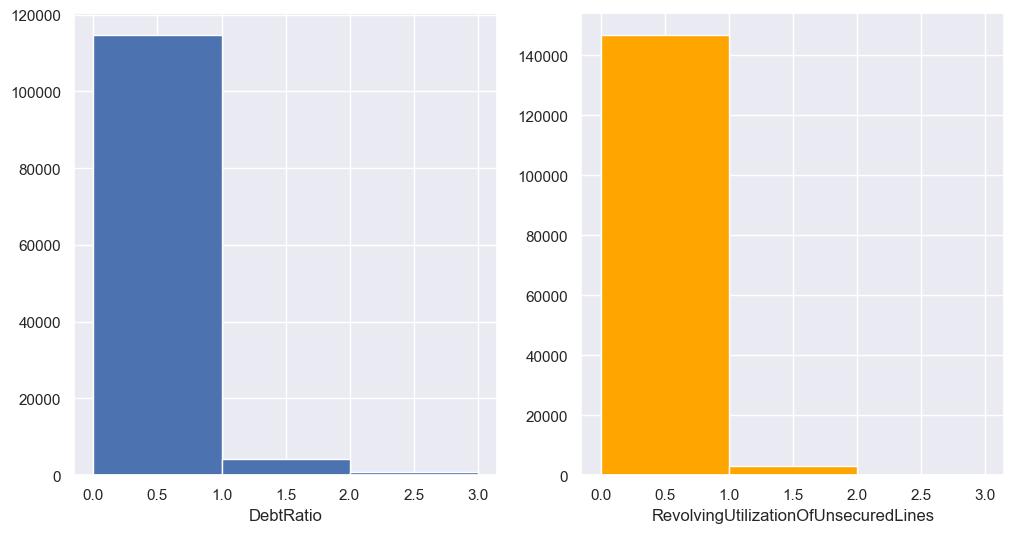

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
final_train['DebtRatio'].hist(bins=range(0, 4, 1), ax=axes[0])
axes[0].set_xlabel('DebtRatio')

final_train['RevolvingUtilizationOfUnsecuredLines'].hist(bins=range(0, 4, 1), ax=axes[1], color='orange')
axes[1].set_xlabel('RevolvingUtilizationOfUnsecuredLines')
plt.show()

Видим значительную разницу между 75-м квантилем и максимальным значением.  
Проведем более глубокий анализ этих столбцов.

**DebtRatio**

In [22]:
quantiles = [0.75, 0.8, 0.81, 0.82, 0.85, 0.9, 0.95, 0.97 ,0.99]

for i in quantiles:
    print(f'{i * 100} quantile of debt ratio:', final_train.DebtRatio.quantile(i))

75.0 quantile of debt ratio: 0.86825377325
80.0 quantile of debt ratio: 4.0
81.0 quantile of debt ratio: 14.0
82.0 quantile of debt ratio: 31.0
85.0 quantile of debt ratio: 269.1499999999942
90.0 quantile of debt ratio: 1267.0
95.0 quantile of debt ratio: 2449.0
97.0 quantile of debt ratio: 3225.0
99.0 quantile of debt ratio: 4979.040000000037


Видим огромный рост после 82-го квантиля. С учетом этого, нашей дальнейшей целью будет проверка потенциальных выбросов, находящихся после 82-го квантиля. Однако, беря во внимание длину нашей выборки, давайте рассмотрим 95-й и 97-й квантили.

In [23]:
final_train[final_train['DebtRatio'] >= final_train['DebtRatio'].quantile(0.95)][['SeriousDlqin2yrs', 'MonthlyIncome']].describe()

,SeriousDlqin2yrs,MonthlyIncome
count,7501.000000,379.000000
mean,0.055193,0.084433
std,0.228371,0.278403
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,1.000000,1.000000


Здесь мы можем наблюдать следующее:

- Из 7501 клиентов, у которых **DebtRatio** (показатель того, во сколько раз их долг превышает доход) превышает 95-й квантиль, только у 379 есть значения **MonthlyIncome**.
- Максимальное значение **MonthlyIncome** здесь равно 1, а минимальное — 0, что наводит на мысль об ошибке ввода данных. Давайте проверим, равны ли значения **SeriousDlqin2yrs** и **MonthlyIncome**.

In [24]:
final_train[(final_train["DebtRatio"] > final_train["DebtRatio"].quantile(0.95)) & (final_train['SeriousDlqin2yrs'] == final_train['MonthlyIncome'])]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
50,0,0.818978,73,0,3095.0,0.0,9,0,1,1,0.0
73,0,0.059669,31,0,3162.0,0.0,11,0,2,0,1.0
90,0,0.039388,51,0,15466.0,0.0,7,0,0,0,0.0
326,0,0.013115,43,0,4211.0,0.0,21,0,2,0,2.0
508,0,1.000000,73,0,8500.0,0.0,2,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
147523,0,0.666509,50,0,4351.0,0.0,12,0,2,0,2.0
148258,0,0.211955,31,0,2734.0,0.0,9,0,1,0,1.0
148432,0,0.091785,37,0,2752.0,0.0,7,0,2,0,3.0
149383,0,0.239302,63,0,3153.0,0.0,29,0,1,0,0.0


Наши подозрения верны — есть 331 из 379 строк, где значения **MonthlyIncome** равны значениям **SeriousDlqin2yrs**. Исходя их этого, мы удалим 331 выброс из выборки, поскольку их текущие значения бесполезны и могут потенциально увеличить смещение и дисперсию.

Это можно обосновать тем, что у нас есть 331 строка, где коэффициент задолженности (**DebtRatio**) огромен по сравнению с доходом клиента (**MonthlyIncome**), и при этом такие клиенты не проверяются на предмет дефолта (**SeriousDlqin2yrs** == 0), что является ничем иным, как ошибкой ввода данных.

In [25]:
final_train = final_train[~((final_train["DebtRatio"] > final_train["DebtRatio"].quantile(0.95)) & (final_train['SeriousDlqin2yrs'] == final_train['MonthlyIncome']))]
final_train

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


**RevolvingUtilizationOfUnsecuredLines**  
  
Данная переменная представляет собой отношение суммы задолженности к кредитному лимиту клиента. Клиент с коэффициентом > 1 считается серьезным неплательщиком. Графики выше показывают, что в таблице есть значения много большие единицы. Например, давайте посмотрим, у скольких из  клиентов **RevolvingUtilizationOfUnsecuredLines** > 10.

In [26]:
final_train[final_train['RevolvingUtilizationOfUnsecuredLines'] > 10].describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,241.000000,241.000000,241.000000,241.000000,241.000000,173.00000,241.000000,241.000000,241.000000,241.000000,228.000000
mean,0.070539,3564.023932,50.630705,0.186722,571.918644,8467.67052,5.763485,0.074689,1.186722,0.087137,0.688596
std,0.256587,5123.802683,14.565389,0.579502,1772.948412,6564.06825,3.114160,0.579711,1.065750,0.559651,1.038659
min,0.000000,11.385230,24.000000,0.000000,0.000800,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,941.000000,39.000000,0.000000,0.217813,4500.00000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,2012.000000,48.000000,0.000000,0.402560,7000.00000,5.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,4116.000000,62.000000,0.000000,59.000000,10091.00000,7.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,87.000000,3.000000,21395.000000,44472.00000,21.000000,8.000000,9.000000,7.000000,4.000000


In [27]:
final_train[final_train['RevolvingUtilizationOfUnsecuredLines'] > 10].sort_values(by='RevolvingUtilizationOfUnsecuredLines').head(7)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
31147,1,11.385230,37,0,0.821643,4333.0,9,0,3,1,0.0
63877,1,12.037116,55,3,0.796490,4500.0,17,0,2,1,1.0
67670,1,12.462747,59,3,0.714789,7667.0,9,1,1,2,0.0
133478,0,14.000000,77,0,282.000000,NaN,7,0,0,0,0.0
113645,0,14.127182,64,3,0.380558,2900.0,3,0,1,1,0.0
16642,1,14.540918,45,3,1.151865,3726.0,11,0,2,7,3.0
132362,0,18.000000,64,0,1428.000000,NaN,4,0,1,0,NaN


In [28]:
final_train[final_train['RevolvingUtilizationOfUnsecuredLines'] > 13]['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    224
1     14
Name: count, dtype: int64

Выбросим все значения переменной **RevolvingUtilizationOfUnsecuredLines** > 13, так как почти все клиенты с такими значениями не рассматриваются как склонные к дефолту, что явно является ошибкой.

In [29]:
final_train = final_train[final_train['RevolvingUtilizationOfUnsecuredLines'] <= 13]
final_train

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


Что ж, теперь выбросы обработаны.  
Далее мы перейдем к обработке пропущенных значений в столбцах **MonthlyIncome** и **NumberOfDependents**.

In [30]:
def nan_handler(df):
    data_missing = df.isnull().sum() * 100 / len(df)
    data_missing_by_column = pd.DataFrame({'Percentage of nulls': data_missing})
    data_missing_by_column.sort_values(by='Percentage of nulls', ascending=False, inplace=True)
    return data_missing_by_column[data_missing_by_column['Percentage of nulls'] > 0]

nan_handler(final_train)

,Percentage of nulls
MonthlyIncome,19.850633
NumberOfDependents,2.617261


In [31]:
nan_handler(final_test)

,Percentage of nulls
MonthlyIncome,19.805326
NumberOfDependents,2.587116


Пропущенные значения в столбце **MonthlyIncome** заменим на медианное значение, а в столбце **NumberOfDependents** на 0 (будем считать, что если количество зависимых от клиента людей не указано, то оно равно нулю).

In [32]:
final_train['MonthlyIncome'].fillna(final_train['MonthlyIncome'].median(), inplace=True)
final_train['NumberOfDependents'].fillna(0, inplace=True)

final_test['MonthlyIncome'].fillna(final_train['MonthlyIncome'].median(), inplace=True)
final_test['NumberOfDependents'].fillna(0, inplace=True)

Построим матрицу корреляций, чтобы лучше познакомиться с датасетом.

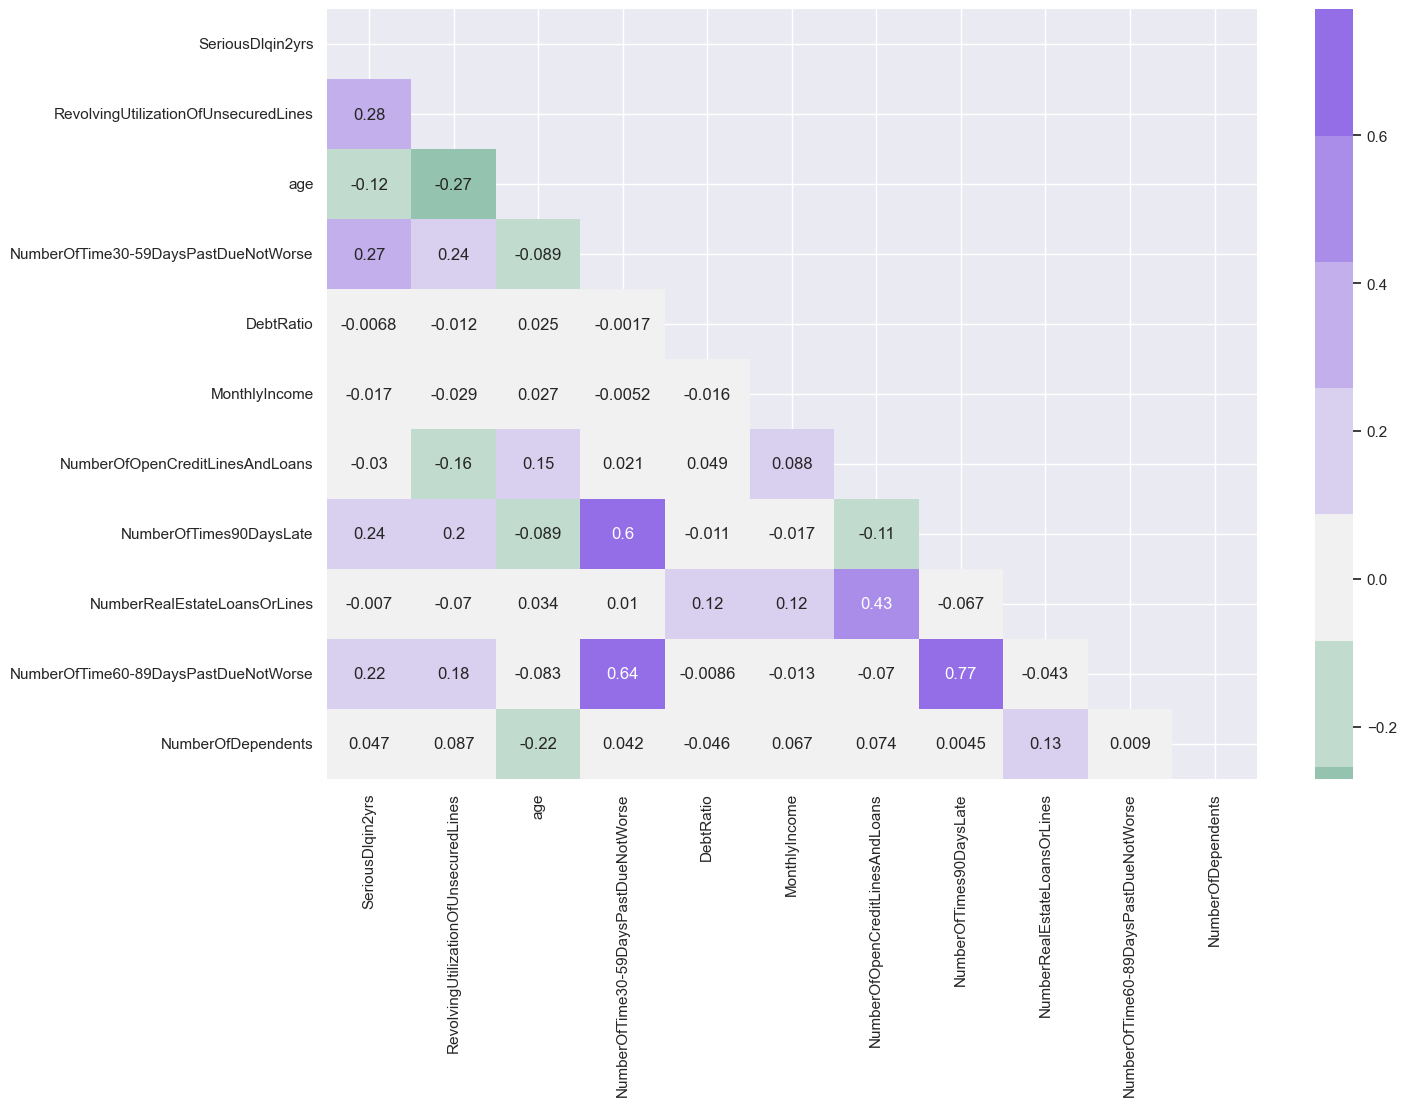

In [33]:
fig = plt.figure(figsize = (15, 10))
mask = np.zeros_like(final_train.corr())
mask[np.triu_indices_from(mask)] = True
sns.heatmap(final_train.corr(), cmap=sns.diverging_palette(150, 275, s=80, l=55, n=9), mask=mask, annot=True, center=0);

Видим, что целевой столбец **SeriousDlqin2yrs** сильнее всего коррелирует со столбцами **RevolvingUtilizationOfUnsecuredLines**, **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTime60-89DaysPastDueNotWorse** и **NumberOfTimes90DaysLate**.

# Feature Engineering

Для начала объединим обучающую и тестовую выборки, чтобы добавить к ним новые признаки.

In [34]:
y = final_train['SeriousDlqin2yrs']
final_train.drop('SeriousDlqin2yrs', axis=1, inplace=True)

In [35]:
final_data = pd.concat([final_train, final_test])
final_data.shape

(250934, 10)

Добавим следующие признаки:

- **MonthlyIncomePerPerson**: Ежемесячный доход, деленный на количество иждивенцев (включая самого клиента)

- **MonthlyDebt**: Ежемесячный доход, умноженный на коэффициент долга (**DebtRatio**)

- **isRetired**: Человек, чей ежемесячный доход равен 0, а возраст превышает 65 лет (предполагаем, что он является пенсионером)

- **RevolvingLines**: Разница между количеством открытых кредитов и кредитных линий (**NumberOfOpenCreditLinesAndLoans**) и количеством кредитов на недвижимость (**NumberRealEstateLoansOrLines**)

- **hasRevolvingLines**: 1, если RevolvingLines > 0, иначе 0

- **hasMultipleRealEstates**: Индикатор того, что у клиента есть больше 2 объектов недвижимости

In [36]:
final_data['MonthlyIncomePerPerson'] = final_data['MonthlyIncome'] / (final_data['NumberOfDependents'] + 1)
final_data['MonthlyDebt'] = final_data['MonthlyIncome'] * final_data['DebtRatio']
final_data['isRetired'] = np.where((final_data['age'] > 65), 1, 0)
final_data['RevolvingLines'] = final_data['NumberOfOpenCreditLinesAndLoans'] - final_data['NumberRealEstateLoansOrLines']
final_data['hasRevolvingLines'] = np.where((final_data['RevolvingLines'] > 0), 1, 0)
final_data['hasMultipleRealEstates'] = np.where((final_data['NumberRealEstateLoansOrLines'] >= 2), 1, 0)

In [37]:
final_data.shape

(250934, 16)

In [38]:
nan_handler(final_data)

,Percentage of nulls


# LightGBM VS XGBoost

In [39]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score
import lightgbm as lgb
import xgboost as xgb
import shap

In [40]:
train_df = final_data[:len(final_train)]
test_df = final_data[len(final_train):]
print(train_df.shape)
print(test_df.shape)

(149431, 16)
(101503, 16)


In [41]:
X_train, X_valid, y_train, y_valid = train_test_split(train_df, y, test_size=0.3, random_state=42)

## LightGBM

In [42]:
%%time
lgb_model = lgb.LGBMClassifier(objective='binary', importance_type='gain', n_jobs=-1, random_state=42, verbose=-1)

lgb_params = {
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.125, 0.15],
    'colsample_bytree': [0.2, 0.4, 0.6, 0.8, 1],
    'n_estimators': [400, 500, 600, 700, 800, 900],
    'min_split_gain': [0.15, 0.20, 0.25, 0.3, 0.35],  # equivalent to gamma in XGBoost
    'subsample': [0.6, 0.7, 0.8, 0.9, 1],
    'min_child_weight': [6, 7, 8, 9, 10],
    'scale_pos_weight': [10, 15, 20],
    'min_data_in_leaf': [100, 200, 300, 400, 500, 600, 700, 800, 900],
    'num_leaves': [20, 30, 40, 50, 60, 70, 80, 90, 100]
}

lgb_rscv = RandomizedSearchCV(lgb_model, lgb_params, scoring='roc_auc', cv=5, random_state=42)

lgb_rscv.fit(X_train, y_train, feature_name=train_df.columns.to_list())

CPU times: total: 13min
Wall time: 2min 5s


RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(importance_type='gain', n_jobs=-1,
                                            objective='binary', random_state=42,
                                            verbose=-1),
                   param_distributions={'colsample_bytree': [0.2, 0.4, 0.6, 0.8,
                                                             1],
                                        'learning_rate': [0.05, 0.1, 0.125,
                                                          0.15],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_child_weight': [6, 7, 8, 9, 10],
                                        'min_data_in_leaf': [100, 200, 300, 400,
                                                             500, 600, 700, 800,
                                                             900],
                                        'min_split_gain': [0.15, 0.2, 0.25, 0.3,
                                                           0.35],
                                        'n_estimators': [400, 500, 600, 700,
                                                         800, 900],
                                        'num_leaves': [20, 30, 40, 50, 60, 70,
                                                       80, 90, 100],
                                        'scale_pos_weight': [10, 15, 20],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1]},
                   random_state=42, scoring='roc_auc')

In [43]:
best_model_lgb = lgb_rscv.best_estimator_
lgb_rscv.best_params_

{'subsample': 0.9,
 'scale_pos_weight': 20,
 'num_leaves': 70,
 'n_estimators': 400,
 'min_split_gain': 0.15,
 'min_data_in_leaf': 300,
 'min_child_weight': 7,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.6}

In [44]:
y_pred_proba_lgb = best_model_lgb.predict_proba(X_valid)[:, 1]
y_pred_lgb = best_model_lgb.predict(X_valid)
print(classification_report(y_valid, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.98      0.75      0.85     41872
           1       0.19      0.82      0.30      2958

    accuracy                           0.75     44830
   macro avg       0.59      0.78      0.58     44830
weighted avg       0.93      0.75      0.81     44830



In [45]:
confusion_matrix(y_valid, y_pred_lgb)

array([[31266, 10606],
       [  524,  2434]], dtype=int64)

In [46]:
fpr, tpr, _ = roc_curve(y_valid, y_pred_proba_lgb)
roc_auc = auc(fpr, tpr)

In [47]:
lgb_metrics = pd.DataFrame({'Model': 'LightGBM', 
                            'AUC ROC': round(roc_auc, 4),
                            'Accuracy Train': round(accuracy_score(best_model_lgb.predict(X_train), y_train) * 100, 2),
                            'Accuracy Valid': round(accuracy_score(y_pred_lgb, y_valid) * 100, 2)}, index=[1])

lgb_metrics

,Model,AUC ROC,Accuracy Train,Accuracy Valid
1,LightGBM,0.869,75.54,75.17


**ROC AUC**

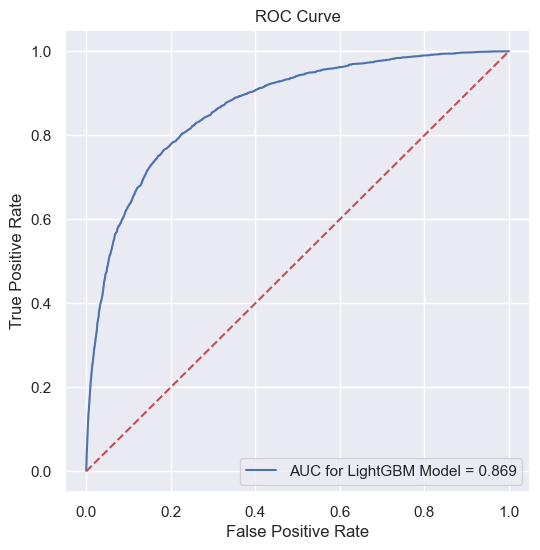

In [48]:
plt.figure(figsize=(6, 6))
plt.title('ROC Curve')
sns.lineplot(x=fpr, y=tpr, label=f'AUC for LightGBM Model = {roc_auc:0.3f}')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

**Feature Importance**

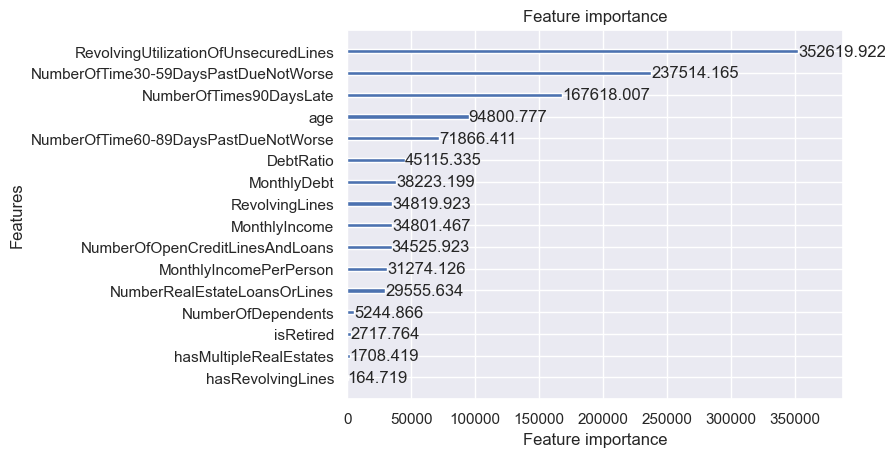

In [49]:
lgb.plot_importance(best_model_lgb, importance_type='gain');

**Feature Importance Using SHAP**

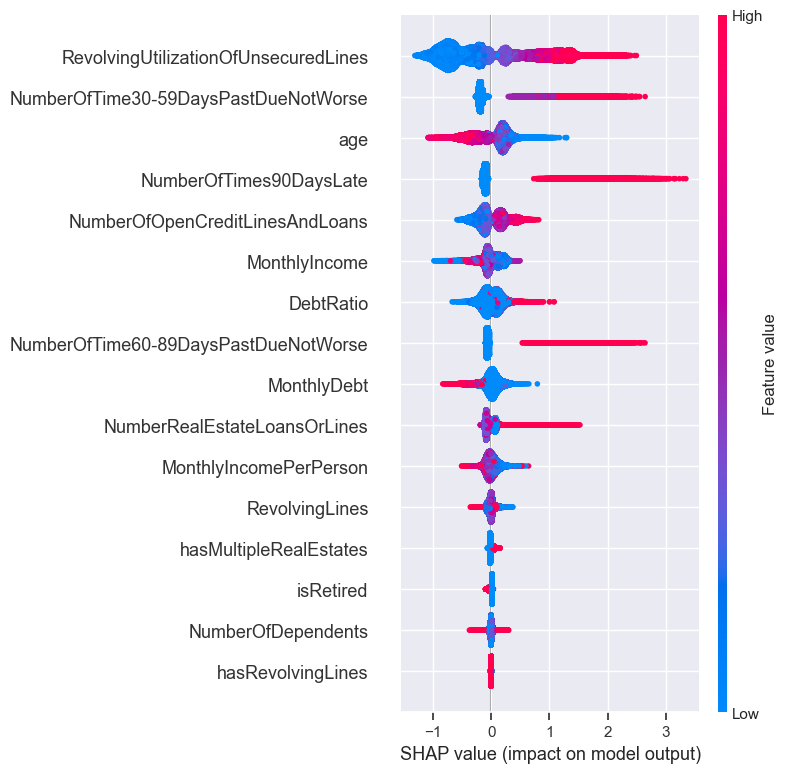

In [50]:
explainer = shap.TreeExplainer(best_model_lgb)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

## XGBoost

In [51]:
%%time
xgb_model = xgb.XGBClassifier(n_jobs=-1, random_state=42, importance_type='gain')

xgb_params = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'learning_rate': [0.05, 0.1, 0.125, 0.15],
    'colsample_bytree': [0.2, 0.4, 0.6, 0.8, 1],
    'n_estimators': [400, 500, 600, 700, 800, 900],
    'gamma': [0.15, 0.20, 0.25, 0.3, 0.35],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1],
    'min_child_weight': [6, 7, 8, 9, 10],
    'scale_pos_weight': [10, 15, 20]
}

xgb_rscv = RandomizedSearchCV(xgb_model, xgb_params, scoring='roc_auc', cv=5, random_state=42)

xgb_rscv.fit(X_train, y_train)

CPU times: total: 33min 30s
Wall time: 5min


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type='gain',
                                           interaction_constraints=None,
                                           learning_ra...
                                           random_state=42, ...),
                   param_distributions={'colsample_bytree': [0.2, 0.4, 0.6, 0.8,
                                                             1],
                                        'gamma': [0.15, 0.2, 0.25, 0.3, 0.35],
                                        'learning_rate': [0.05, 0.1, 0.125,
                                                          0.15],
                                        'max_depth': [2, 3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [6, 7, 8, 9, 10],
                                        'n_estimators': [400, 500, 600, 700,
                                                         800, 900],
                                        'scale_pos_weight': [10, 15, 20],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1]},
                   random_state=42, scoring='roc_auc')

In [52]:
best_model_xgb = xgb_rscv.best_estimator_
xgb_rscv.best_params_

{'subsample': 0.9,
 'scale_pos_weight': 10,
 'n_estimators': 500,
 'min_child_weight': 6,
 'max_depth': 2,
 'learning_rate': 0.15,
 'gamma': 0.3,
 'colsample_bytree': 0.4}

In [53]:
y_pred_proba_xgb = best_model_xgb.predict_proba(X_valid)[:, 1]
y_pred_xgb = best_model_xgb.predict(X_valid)
print(classification_report(y_valid, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.87      0.92     41872
           1       0.27      0.70      0.39      2958

    accuracy                           0.86     44830
   macro avg       0.62      0.78      0.65     44830
weighted avg       0.93      0.86      0.88     44830



In [54]:
confusion_matrix(y_valid, y_pred_xgb)

array([[36268,  5604],
       [  884,  2074]], dtype=int64)

In [55]:
fpr, tpr, _ = roc_curve(y_valid, y_pred_proba_xgb)
roc_auc = auc(fpr, tpr)

In [56]:
xgb_metrics = pd.DataFrame({'Model': 'XGBoost', 
                            'AUC ROC': round(roc_auc, 4),
                            'Accuracy Train': round(accuracy_score(best_model_xgb.predict(X_train), y_train) * 100, 2),
                            'Accuracy Valid': round(accuracy_score(y_pred_xgb, y_valid) * 100, 2)}, index=[2])

xgb_metrics

,Model,AUC ROC,Accuracy Train,Accuracy Valid
2,XGBoost,0.8686,85.37,85.53


**ROC AUC**

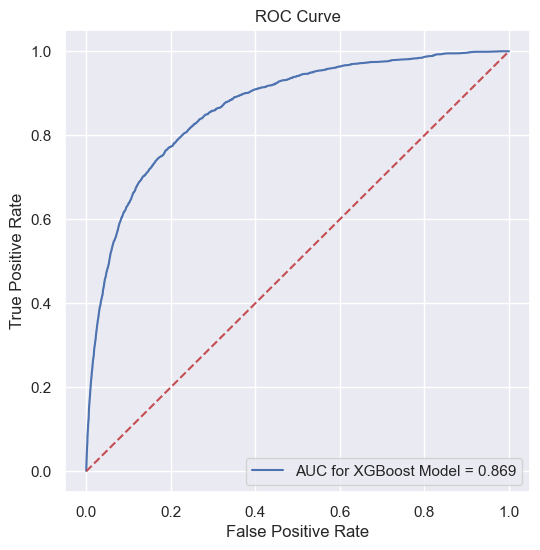

In [57]:
plt.figure(figsize=(6, 6))
plt.title('ROC Curve')
sns.lineplot(x=fpr, y=tpr, label=f'AUC for XGBoost Model = {roc_auc:0.3f}')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

**Feature Importance**

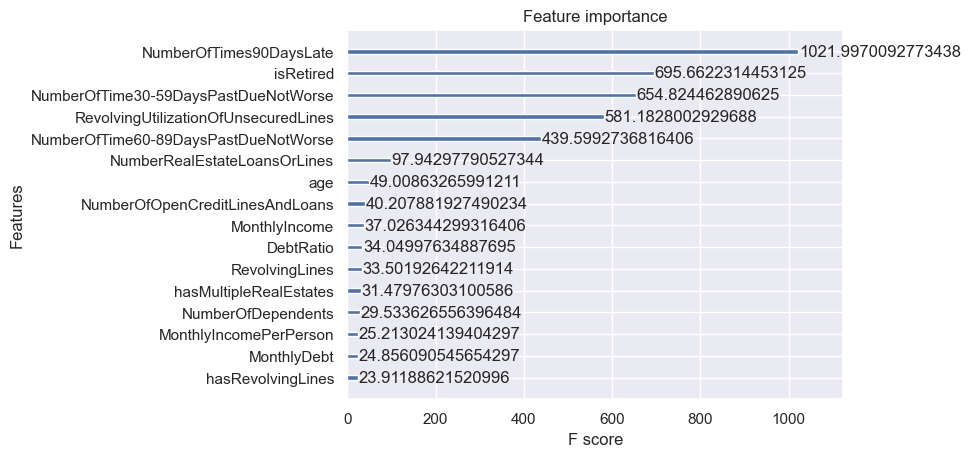

In [58]:
best_model_xgb.get_booster().feature_names = train_df.columns.to_list()
xgb.plot_importance(best_model_xgb, importance_type='gain');

**Feature Importance Using SHAP**

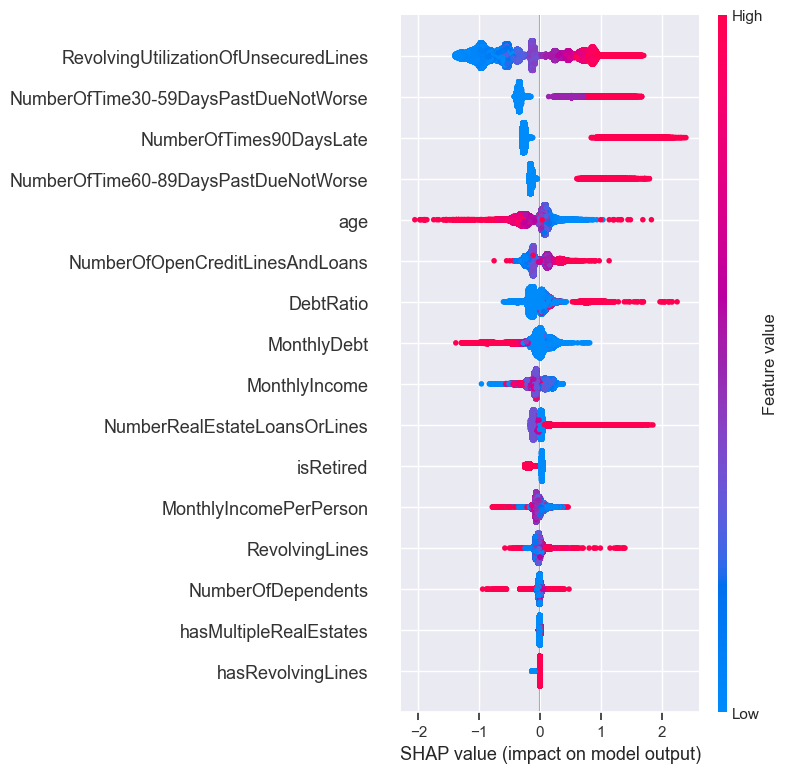

In [59]:
explainer = shap.TreeExplainer(best_model_xgb.get_booster())
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

In [60]:
frames = [lgb_metrics, xgb_metrics]
TrainingResult = pd.concat(frames)
TrainingResult.T

,1,2
Model,LightGBM,XGBoost
AUC ROC,0.869,0.8686
Accuracy Train,75.54,85.37
Accuracy Valid,75.17,85.53


Видим, что ROC-AUC чуть лучше у LightGBM-модели, а accuracy сильно лучше у XGBoost-модели.

# Submission

Посмотрим, какая модель справится с задачей лучше.

In [61]:
lgb_probs = best_model_lgb.predict_proba(test_df)
lgb_df = pd.DataFrame({'Id': list(range(1, final_test.shape[0] + 1)), 'Probability': lgb_probs[:, 1]})
lgb_df.to_csv('submission_lgb2.csv', index=False)

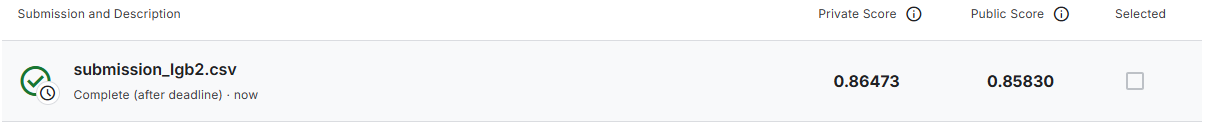

In [62]:
xgb_probs = best_model_xgb.predict_proba(test_df)
xgb_df = pd.DataFrame({'Id': list(range(1, final_test.shape[0] + 1)), 'Probability': xgb_probs[:, 1]})
xgb_df.to_csv('submission_xgb.csv', index=False)

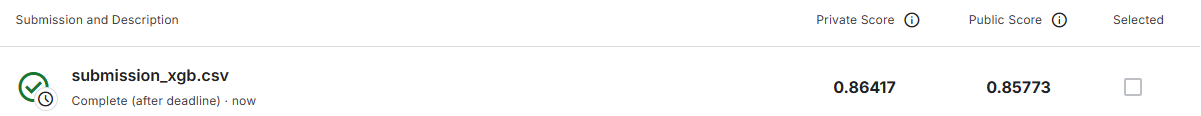

Получили отличный результат, учитывая, что наилучший Private Score в соревновании был равен *0.86955*